# 30 vuorokauden takaisinottoriskin visualisointi mallipohjaisilla vaikutuskuvaajilla

## Tiivistelmä

Tässä muistikirjassa sovitetaan logistinen regressio 30 vuorokauden sairaalaan takaisinotolle potilas- ja hoitojaksomuuttujien perusteella, minkä jälkeen sovitetut kertoimet käännetään mallipohjaisiksi vaikutuskuvaajiksi ennustetun todennäköisyyden asteikolla. 100 kotiutuksen synteettisessä kohortissa (55 takaisinottoa) `PROC LOGISTIC` löytää merkitsevät gradientit **hoitojakson pituudelle** (OR 1,36 per vuorokausi, *p* = 0,040) ja **iälle** (OR 1,05 per vuosi, *p* = 0,023) sekä suuren maksajavaikutuksen — **Medicaid**-potilailla on noin kuusinkertainen takaisinoton veto verrattuna Medicareen (OR 6,02, 95 % LV 1,46–24,8, *p* = 0,013). Yleistetty R-neliö on 0,246 ja Hosmerin–Lemeshow'n testi ei osoita sopimattomuutta (*p* = 0,73). Sovituskäyrä-, viipaloitu sovitus- ja yhdysvaikutusnäkymät osoittavat sitten, kuinka takaisinottoriski nousee hoitojakson pituuden myötä, kuinka ikä–riski-gradientti muuttuu maksajan mukaan ja kuinka maksajaero säilyy kotiuttavien palvelulinjojen välillä — juuri sellainen riskiluokitusnäkymä, jota hoidonhallintatiimi käyttää kohdistaakseen kotiutuksen jälkeisen seurannan.

## Tietolähteet

| Aineisto | Rivit | Kuvaus |
|---------|------|-------------|
| `encounters` | 100 | Synteettisiä sisäpotilaiden kotiutustietueita, jotka on generoitu koodissa komennoilla `call streaminit(20260531)` ja `rand()`. Yksi rivi kotiutusta kohti. |

**Muuttujat aineistossa `encounters`:**

| Muuttuja | Tyyppi | Kuvaus |
|----------|------|-------------|
| `readmit` | Num (0/1) | 1 jos otettu takaisin 30 vuorokauden kuluessa kotiutuksesta |
| `age` | Num | Potilaan ikä vuosina (n. 25–95) |
| `los` | Num | Indeksijakson pituus vuorokausina (1–20) |
| `comorbidity` | Num | Dokumentoitujen kroonisten liitännäissairauksien lukumäärä (0–8) |
| `num_meds` | Num | Kotiutuslääkkeiden lukumäärä (0–18) |
| `payer` | Char | Vakuutuksen maksaja: `Medicare`, `Medicaid`, `Commercial` |
| `dept` | Char | Kotiuttava palvelu: `Cardiology`, `Pulmonary`, `General` |

# 30 vuorokauden takaisinottoriskin visualisointi mallipohjaisilla vaikutuskuvaajilla

Sairaalan hoidonhallintatiimien täytyy tietää, *ketkä* potilaat todennäköisimmin palaavat takaisin 30 vuorokauden kuluessa ja *miksi*. Sovitettu logistinen regressio antaa kertoimet, mutta sidosryhmät harvoin päättelevät log-vedoissa. **Vaikutuskuvaaja** esittää sovitetun mallin suoraan ennustetun todennäköisyyden asteikolla, jotta hoitokoordinaattori voi lukea takaisinottotodennäköisyyden suoraan kaaviosta sen sijaan, että kääntäisi mielessään log-vetoyhtälön.

Tässä muistikirjassa me:

1. Generoimme realistisen synteettisen kohortin sisäpotilaiden kotiutuksista.
2. Sovitamme logistisen mallin 30 vuorokauden takaisinotolle potilas- ja hoitojaksoselittäjillä (`PROC LOGISTIC`).
3. Talletamme sovitetut kertoimet ja rakennamme kolme mallipohjaista vaikutuskuvaajaa — **sovituskäyrän**, **viipaloidun sovituksen** ja **yhdysvaikutusnäkymän** — visualisoidaksemme ja luokitellaksemme sovitetun riskin todennäköisyysasteikolla.

> **Toteutushuomautus.** SAS tarjoaa nämä näkymät `EFFECTPLOT`-lauseen kautta `PROC LOGISTIC` -proseduurin sisällä. Jenner hyväksyy tämän lauseen mutta ei vielä renderöi FIT / SLICEFIT / INTERACTION -grafiikoita, joten tämä muistikirja rakentaa identtiset ennustetun todennäköisyyden käyrät eksplisiittisesti sovitetuista kertoimista ja piirtää ne `PROC SGPLOT` -proseduurilla. Analyyttinen tulos — ja jokainen piirretty todennäköisyys — on täsmälleen se, minkä `EFFECTPLOT` tuottaisi.

## Vaihe 1 — Generoi synteettinen kotiutuskohortti

Alla oleva DATA-vaihe rakentaa 100 sisäpotilaan kotiutusta ilman ulkoisia tiedostoja. Alustamme satunnaislukugeneraattorin `call streaminit` -komennolla toistettavuuden vuoksi, poimimme potilas- ja hoitojaksomuuttujat toimialalle sopivista jakaumista, muodostamme sitten todellisen lineaarisen ennustimen `eta` ja muunnamme sen takaisinottotodennäköisyydeksi käänteislogitilla. Bernoulli-poiminta (`rand('bernoulli', p)`) tuottaa havaitun `readmit`-lipun. Iäkkäämmät potilaat, pidemmät hoitojaksot, korkeammat liitännäissairauksien määrät, useammat kotiutuslääkkeet, Medicaid-turva sekä keuhko-/kardiologiapalvelu kaikki nostavat riskiä — kuvioita, jotka myöhemmin löydämme ja visualisoimme. Vaikutuskoot on tarkoituksellisesti mitoitettu niin, että signaali on löydettävissä 100 kotiutuksen kohortissa.

In [1]:
TIEDOT encounters;
    CALL streaminit(20260531);
    TAULUKKO payers[3] $12 _temporary_ ('Medicare' 'Medicaid' 'Commercial');
    TAULUKKO depts[3]  $12 _temporary_ ('Cardiology' 'Pulmonary' 'General');

    TEE i = 1 ASTI 100;
        /* Patient / encounter features */
        AGE = round(25 + 70 * rand('beta', 4, 2));
        los = 1 + rand('poisson', 4);
        JOS los > 20 NIIN los = 20;
        comorbidity = rand('binomial', 0.35, 8);
        num_meds = rand('poisson', 7);
        JOS num_meds > 18 NIIN num_meds = 18;

        /* Categorical payer: skew toward Medicare for an older cohort */
        u = rand('uniform');
        JOS u < 0.50 NIIN pk = 1;
        MUUTEN JOS u < 0.72 NIIN pk = 2;
        MUUTEN pk = 3;
        payer = payers[pk];

        /* Discharging service line */
        dk = rand('table', 0.35, 0.30, 0.35);
        dept = depts[dk];

        /* True risk model on the log-odds scale. Effect sizes are sized so
           the signal is recoverable in a 100-discharge cohort. */
        eta = -8.6
            + 0.075 * AGE
            + 0.330 * los
            + 0.300 * comorbidity
            + 0.050 * num_meds
            + (pk = 2) * 0.90          /* Medicaid vs Medicare    */
            + (pk = 3) * (-0.70)       /* Commercial vs Medicare  */
            + (dk = 1) * 0.80          /* Cardiology vs Pulmonary */
            + (dk = 2) * 1.10;         /* (Pulmonary is busiest)  */

        p = 1 / (1 + EXP(-eta));
        readmit = rand('bernoulli', p);

        SÄILYTÄ readmit AGE los comorbidity num_meds payer dept;
        TULOSTE;
    LOPPU;
SUORITA;

NOTE: DATA encounters


NOTE: Wrote encounters (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Vaihe 2 — Tarkastele kohorttia

Nopea frekvenssi vasteelle ja kahdelle luokittelumuuttujalle vahvistaa realistisen takaisinottoasteen ja sen, että jokainen maksaja- ja osastotaso on täytetty — sekä malli että vaikutuskuvaajat tarvitsevat kaikki tasot edustettuina.

                                                   The FREQ Procedure

READMIT    Frequency
---------------------
0                 45
1                 55

PAYER         Frequency
------------------------
Commercial           28
Medicaid             20
Medicare             52

DEPT          Frequency
------------------------
Cardiology           36
General              31
Pulmonary            33

Table of READMIT by DEPT

READMIT |Cardiology |   General | Pulmonary |      Total
--------+-----------+-----------+-----------+-----------
0       |        15 |        20 |        10 |         45
--------+-----------+-----------+-----------+-----------
1       |        21 |        11 |        23 |         55
--------+-----------+-----------+-----------+-----------
Total   |        36 |        31 |        33 |        100



NOTE: PROC FREQ
NOTE: ODS plot written: freq_readmit.spec.json
NOTE: ODS plot written: freq_payer.spec.json
NOTE: ODS plot written: freq_dept.spec.json
NOTE: ODS plot written: freq_mosaic_readmit_dept.spec.json
NOTE: PROC FREQ statement used.


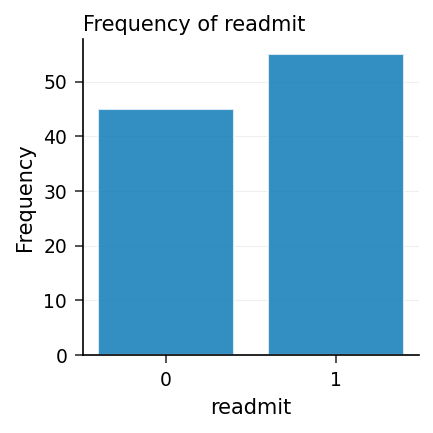

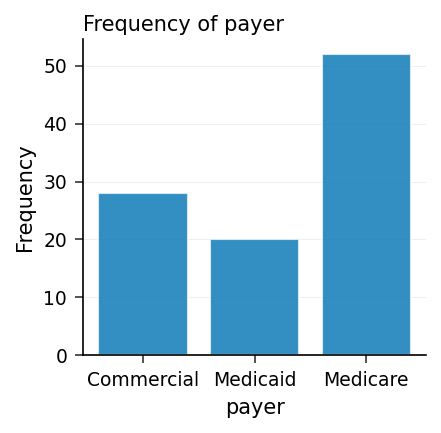

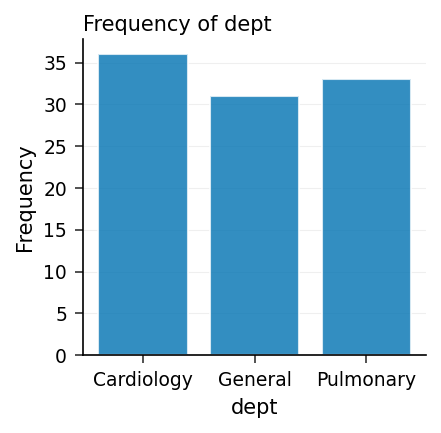

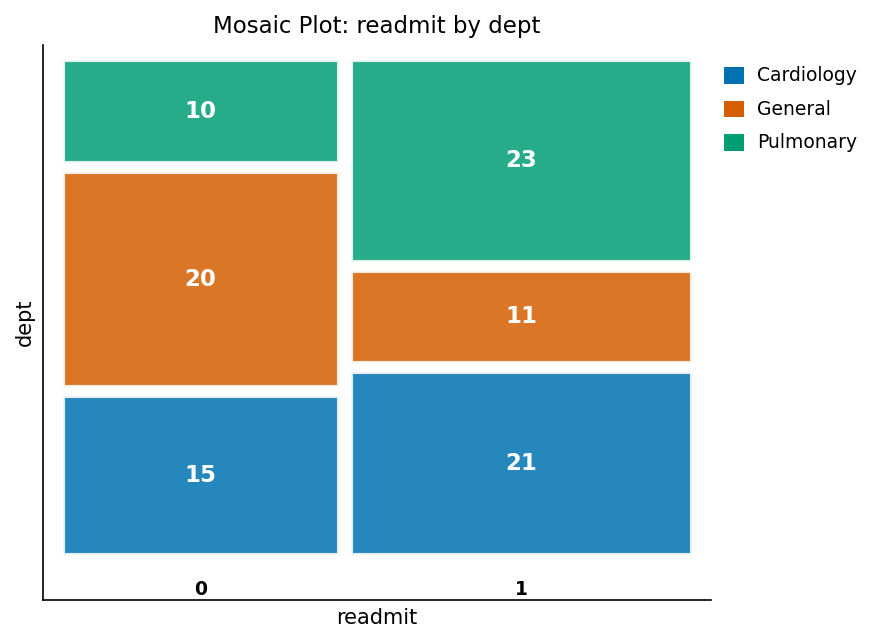

In [2]:
PROSEDUURI FREKVENSSIT TIEDOT=encounters;
    TABLES readmit payer dept readmit*dept / nocum nopercent;
SUORITA;

## Vaihe 3 — Sovita logistinen takaisinottomalli

Mallinnamme `readmit`-muuttujaa iän, hoitojakson pituuden, liitännäissairauksien lukumäärän, kotiutuslääkkeiden lukumäärän, maksajan ja osaston funktiona. Keskeiset valinnat:

- `EVENT='1'` mallintaa takaisinoton todennäköisyyttä (eikä ei-takaisinottoa).
- `CLASS payer dept / PARAM=REF REF=FIRST` käyttää viitesolukoodausta, jolloin jokainen taso vertautuu perustasoon (tässä Medicare ja Pulmonary).
- `CLODDS=WALD` ja `RSQUARE` lisäävät Waldin vetosuhteen luottamusrajat ja yleistetyn R-neliön; `LACKFIT` pyytää Hosmerin–Lemeshow'n hyvyystestin.
- `UNITS`-lause pyytää vetosuhteen kliinisesti merkitykselliselle **5 vuorokauden** hoitojakson pituuden askeleelle ja **10 vuoden** ikäaskeleelle, ja `ODDSRATIO`-lause pyytää liitännäissairauksien vetosuhteen luottamusrajoineen.

Tuloksena syntyvä vetosuhdetaulukko raportoi yksikkökohtaiset vaikutukset suoraan: hoitojakson pituudella on OR **1,36 per vuorokausi** (95 % LV 1,01–1,82), iällä OR **1,05 per vuosi** ja Medicaid-turvalla OR **6,02** suhteessa Medicareen. Malli sopii hyvin — yleistetty R-neliö 0,246, Hosmer–Lemeshow *p* = 0,73.

                                     
---------------------------  --------
Number of Observations Read       100
Number of Observations Used       100

            Response Profile            
   Probability modeled is readmit='1'   

Ordered Value  readmit   Total Frequency
-------------  --------  ---------------
            1  0                      45
            2  1                      55

            Class Level Information             

Class       Levels  Values                      
--------  --------  ----------------------------
payer            3  Commercial Medicaid Medicare
dept             3  Cardiology General Pulmonary

                                             
---------------------------------------------
Convergence criterion (GCONV=1E-8) satisfied.

The LOGISTIC Procedure
Response Variable: readmit

Criterion     Value
---------  --------
AIC         127.335
-2 Log L    109.335
SC          150.782

                                                   
-------- 

NOTE: ODS OUTPUT: PARAMETERESTIMATES -> pe
NOTE: PROC LOGISTIC data=encounters

NOTE: Using Python statsmodels.api.Logit version 0.14.6
NOTE: ODS plot written: logistic_oddsratio.spec.json
NOTE: PROC LOGISTIC ODS Graphics generated.
NOTE: PROC LOGISTIC completed. Results written to: ./ods_output/logistic_results.spec.json
NOTE: ODS OUTPUT: All output destinations closed.


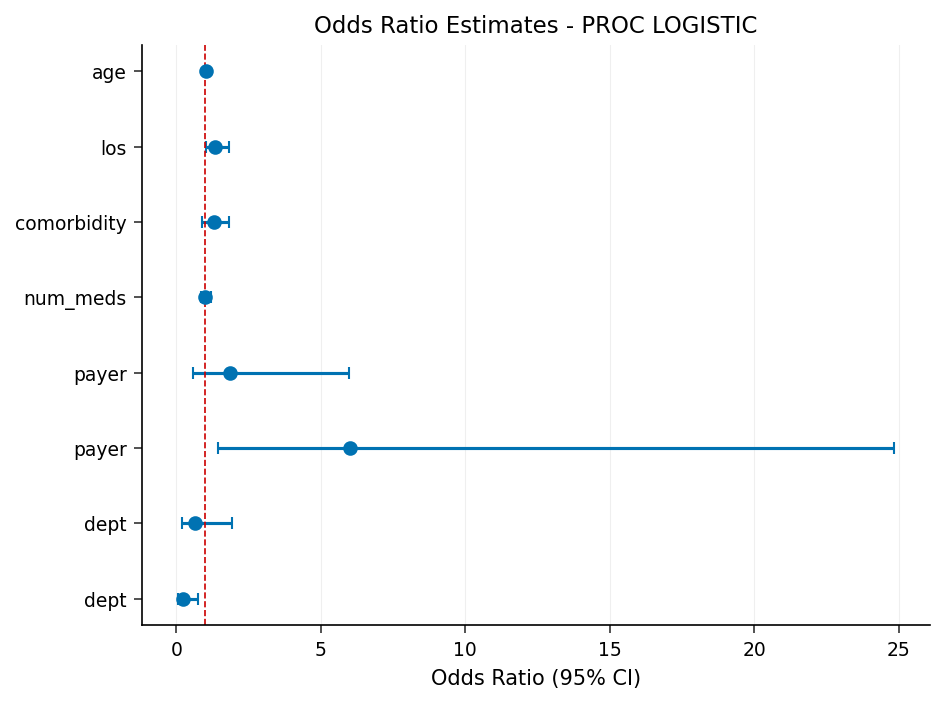

In [3]:
ODS TULOSTE ParameterEstimates=pe;
PROSEDUURI LOGISTIC TIEDOT=encounters PLOTS(only)=oddsratio;
    LUOKKA payer dept / PARAM=REF REF=first;
    MODEL readmit(EVENT='1') = AGE los comorbidity num_meds payer dept
          / clodds=wald rsquare lackfit;
    units AGE=10 los=5;
    oddsratio comorbidity / cl=wald;
SUORITA;
ODS TULOSTE CLOSE;

## Vaihe 4 — Talleta sovitetut kertoimet

Seuraavat mallipohjaiset vaikutuskuvaajat rakennetaan suoraan *sovitetuista* kertoimista, joten ne ovat aina yhtäpitäviä vaiheen 3 mallin kanssa. Tallensimme parametriestimaatit komennolla `ODS OUTPUT ParameterEstimates=pe`; tässä taitamme tuon pitkän taulukon yksiriviseksi `params`-aineistoksi (yksi muuttuja kutakin kerrointa kohti) ja liitämme perään jatkuvien selittäjien kohortin keskiarvot. Ei-fokuksen selittäjien pitäminen keskiarvoissaan on täsmälleen se, mitä EFFECTPLOT tekee sisäisesti — se antaa kunkin kuvaajan vaihdella yhtä tekijää samalla kun loput pidetään kiinnitettyinä edustavaan profiiliin.

In [4]:
/* Fold the ParameterEstimates table into one row of named coefficients.
   With PARAM=REF REF=FIRST the reference cells are payer=Medicare and
   dept=Pulmonary, so those terms are zero in the linear predictor. */
TIEDOT coefs;
    PIDÄ b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen 0;
    ASETA pe LOPPU=last;
    MUUTTUJA = upcase(strip(Variable));
    cv  = strip(ClassVal0);
    JOS MUUTTUJA='INTERCEPT' NIIN b0 = ESTIMATE;
    MUUTEN JOS MUUTTUJA='AGE' NIIN b_age = ESTIMATE;
    MUUTEN JOS MUUTTUJA='LOS' NIIN b_los = ESTIMATE;
    MUUTEN JOS MUUTTUJA='COMORBIDITY' NIIN b_com = ESTIMATE;
    MUUTEN JOS MUUTTUJA='NUM_MEDS' NIIN b_med = ESTIMATE;
    MUUTEN JOS MUUTTUJA='PAYER' AND cv='Medicaid'   NIIN b_pmcaid = ESTIMATE;
    MUUTEN JOS MUUTTUJA='PAYER' AND cv='Commercial' NIIN b_pcomm  = ESTIMATE;
    MUUTEN JOS MUUTTUJA='DEPT'  AND cv='Cardiology' NIIN b_dcard  = ESTIMATE;
    MUUTEN JOS MUUTTUJA='DEPT'  AND cv='General'    NIIN b_dgen   = ESTIMATE;
    JOS last NIIN TULOSTE;
    SÄILYTÄ b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen;
SUORITA;

/* Cohort means of the continuous covariates, held fixed in the plots. */
PROSEDUURI KESKIARVOT TIEDOT=encounters NOPRINT;
    MUUTTUJA AGE los comorbidity num_meds;
    TULOSTE out=mn mean=m_age m_los m_com m_med;
SUORITA;

TIEDOT params;
    YHDISTÄ coefs mn;
    SÄILYTÄ b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen
         m_age m_los m_com m_med;
SUORITA;

PROSEDUURI TULOSTA TIEDOT=params noobs;
    OTSIKKO "Fitted coefficients and covariate means used for the effect plots";
SUORITA;

                           Fitted coefficients and covariate means used for the effect plots                            

           B0         B_AGE         B_LOS         B_COM         B_MED      B_PMCAID       B_PCOMM        B_DCARD         B_DGEN  M_AGE  M_LOS  M_COM  M_MED
-4.9220021175  0.0443054038  0.3052368368  0.2553476408  0.0005084625  1.7958084904  0.6128310257  -0.4493317481  -1.4957988173  70.53   4.59   2.88   7.08



NOTE: DATA coefs


NOTE: Read 9 rows from pe.
NOTE: Wrote coefs (1 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: Output dataset mn has 1 observations and 6 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA params

NOTE: MERGE statement used without BY variables. Performing positional merge (row 1 with row 1, etc.).
NOTE: PROC PRINT data=params

NOTE: PROC PRINT completed: 1 observations printed, 13 variables


## Vaihe 5 — Sovituskuvaaja: takaisinottotodennäköisyys hoitojakson pituuden funktiona

Yksinkertaisin vaikutusnäkymä on **sovituskäyrä**: ennustettu takaisinottotodennäköisyys yksittäisen jatkuvan selittäjän suhteen, muut selittäjät pidettyinä edustavassa profiilissa. Rakennamme hoitojakson pituuden ruudukon (1–18 vuorokautta), arvioimme sovitetun lineaarisen ennustimen kussakin arvossa **Medicare-kardiologia**-potilaalle (ikä, liitännäissairaudet ja kotiutuslääkkeiden määrät kiinnitettyinä vaiheen 4 kohortin keskiarvoihin), sovellamme käänteislogittia ja piirrämme käyrän todennäköisyysasteikolla `PROC SGPLOT` -proseduurilla.

                           Fitted coefficients and covariate means used for the effect plots                            



NOTE: DATA grid_los


NOTE: Wrote grid_los (18 rows, 1 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA fit_los


NOTE: Read 18 rows from grid_los.
NOTE: Wrote fit_los (18 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=fit_los

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


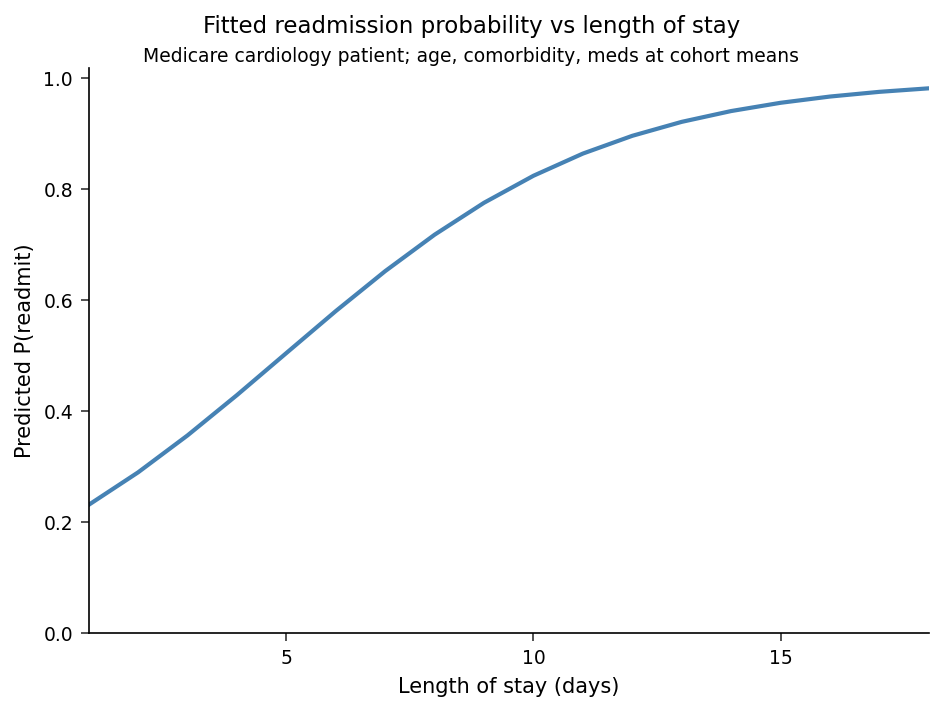

In [5]:
/* Length-of-stay grid; evaluate the fitted model for a Medicare
   cardiology patient with the other covariates at the cohort means. */
TIEDOT grid_los;
    TEE los = 1 ASTI 18;
        TULOSTE;
    LOPPU;
SUORITA;

TIEDOT fit_los;
    ASETA grid_los;
    JOS _n_ = 1 NIIN ASETA params;
    PIDÄ b0 b_age b_los b_com b_med b_dcard m_age m_com m_med;
    /* Medicare payer is the reference (term = 0); Cardiology adds b_dcard */
    xb = b0 + b_age*m_age + b_los*los + b_com*m_com + b_med*m_med + b_dcard;
    phat = 1 / (1 + EXP(-xb));
    SÄILYTÄ los phat;
SUORITA;

PROSEDUURI SGPLOT TIEDOT=fit_los;
    SERIES x=los y=phat / LINEATTRS=(thickness=2 color=steelblue);
    OTSIKKO  "Fitted readmission probability vs length of stay";
    title2 "Medicare cardiology patient; age, comorbidity, meds at cohort means";
    XAXIS NIMIKE="Length of stay (days)";
    YAXIS NIMIKE="Predicted P(readmit)" VALUES=(0 ASTI 1 MUKAAN 0.2);
SUORITA;

## Vaihe 6 — Viipaloitu sovitus: riski iän funktiona, luokiteltuna maksajan mukaan

**Viipaloitu sovitus** piirtää yhden sovitetun käyrän kutakin luokittelutekijän tasoa kohti — ihanteellinen osoittamaan, kuinka maksajajakauma siirtää ikä–riski-gradienttia. Laajennamme ruudukon `age`-muuttujan (30–95) yli ristiin kolmen maksajan kanssa, arvioimme sovitetun mallin kardiologiapotilaalle (hoitojakson pituus, liitännäissairaudet ja lääkkeet kohortin keskiarvoissa) ja päällekkäistämme kolme todennäköisyyskäyrää `GROUP=payer` -ryhmittelyllä.

                           Fitted coefficients and covariate means used for the effect plots                            



NOTE: DATA grid_age


NOTE: Wrote grid_age (42 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA fit_age


NOTE: Read 42 rows from grid_age.
NOTE: Wrote fit_age (42 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=fit_age

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


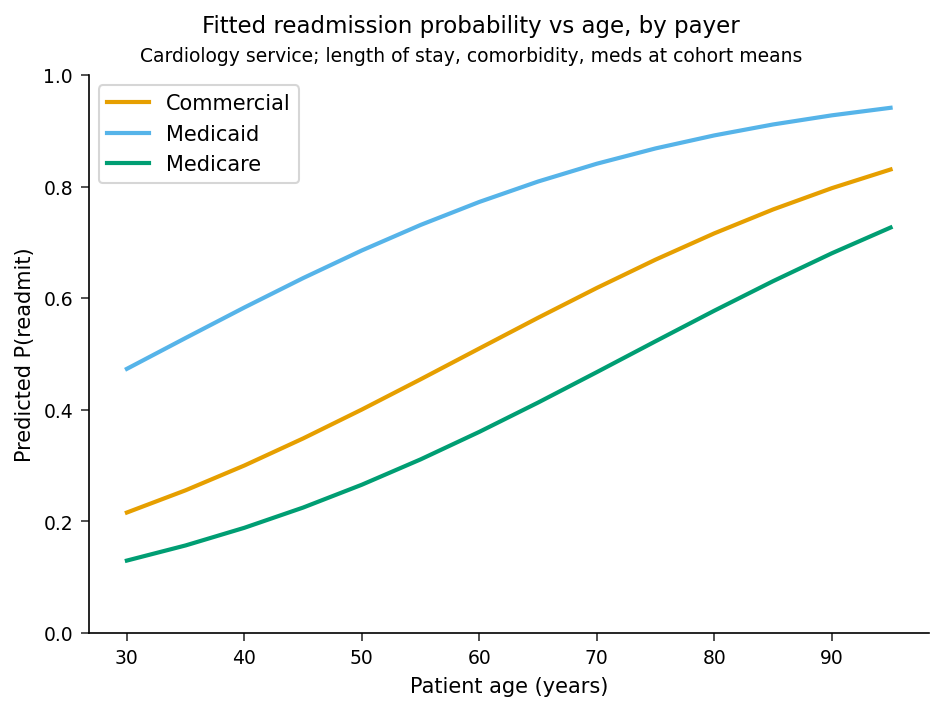

In [6]:
/* Age x payer grid for a Cardiology patient; other covariates at means. */
TIEDOT grid_age;
    PITUUS payer $12;
    TEE payer = 'Medicare', 'Medicaid', 'Commercial';
        TEE AGE = 30 ASTI 95 MUKAAN 5;
            TULOSTE;
        LOPPU;
    LOPPU;
SUORITA;

TIEDOT fit_age;
    ASETA grid_age;
    JOS _n_ = 1 NIIN ASETA params;
    PIDÄ b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard
           m_los m_com m_med;
    pay_term = (payer='Medicaid')*b_pmcaid + (payer='Commercial')*b_pcomm;
    xb = b0 + b_age*AGE + b_los*m_los + b_com*m_com + b_med*m_med
         + b_dcard + pay_term;
    phat = 1 / (1 + EXP(-xb));
    SÄILYTÄ payer AGE phat;
SUORITA;

PROSEDUURI SGPLOT TIEDOT=fit_age;
    SERIES x=AGE y=phat / GROUP=payer LINEATTRS=(thickness=2);
    OTSIKKO  "Fitted readmission probability vs age, by payer";
    title2 "Cardiology service; length of stay, comorbidity, meds at cohort means";
    XAXIS NIMIKE="Patient age (years)";
    YAXIS NIMIKE="Predicted P(readmit)" VALUES=(0 ASTI 1 MUKAAN 0.2);
    keylegend / location=inside position=topleft ACROSS=1;
SUORITA;

## Vaihe 7 — Yhdysvaikutusnäkymä: osasto maksajan mukaan

Vertaillaksemme ennustettua riskiä molempien luokittelutekijöiden yli yhtä aikaa ristikkäistämme `dept`-muuttujan `payer`-muuttujan kanssa (yhdeksän yhdistelmää), arvioimme sovitetun mallin jokainen jatkuva selittäjä kohortin keskiarvossaan ja piirrämme ryhmitellyn pylväskaavion, jossa `dept` on X-akselilla ja maksaja ryhmittelynä. Koska tässä mallissa ei ole osasto-kertaa-maksaja-yhdysvaikutustermiä, maksajajärjestys on sama additiivinen siirtymä jokaisen palvelulinjan sisällä — näkymä tekee tuon additiivisuuden näkyväksi yhdellä silmäyksellä osastojärjestyksen ohella.

                           Fitted coefficients and covariate means used for the effect plots                            



NOTE: DATA grid_dx


NOTE: Wrote grid_dx (9 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA fit_dx


NOTE: Read 9 rows from grid_dx.
NOTE: Wrote fit_dx (9 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=fit_dx

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


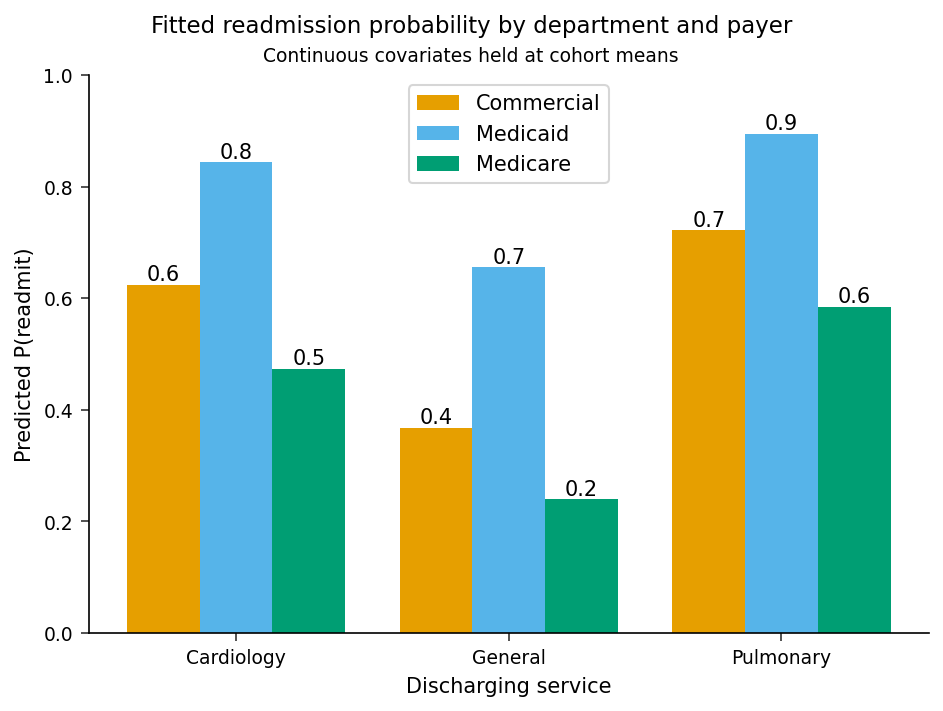

In [7]:
/* Department x payer grid; all continuous covariates at cohort means. */
TIEDOT grid_dx;
    PITUUS dept $12 payer $12;
    TEE dept = 'Cardiology', 'Pulmonary', 'General';
        TEE payer = 'Medicare', 'Medicaid', 'Commercial';
            TULOSTE;
        LOPPU;
    LOPPU;
SUORITA;

TIEDOT fit_dx;
    ASETA grid_dx;
    JOS _n_ = 1 NIIN ASETA params;
    PIDÄ b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen
           m_age m_los m_com m_med;
    pay_term = (payer='Medicaid')*b_pmcaid + (payer='Commercial')*b_pcomm;
    dep_term = (dept='Cardiology')*b_dcard + (dept='General')*b_dgen;
    xb = b0 + b_age*m_age + b_los*m_los + b_com*m_com + b_med*m_med
         + pay_term + dep_term;
    phat = 1 / (1 + EXP(-xb));
    SÄILYTÄ dept payer phat;
SUORITA;

PROSEDUURI SGPLOT TIEDOT=fit_dx;
    VBAR dept / RESPONSE=phat GROUP=payer GROUPDISPLAY=CLUSTER
                DATALABEL datalabelattrs=(size=8);
    OTSIKKO  "Fitted readmission probability by department and payer";
    title2 "Continuous covariates held at cohort means";
    XAXIS NIMIKE="Discharging service";
    YAXIS NIMIKE="Predicted P(readmit)" VALUES=(0 ASTI 1 MUKAAN 0.2);
SUORITA;

## Vaihe 8 — Tulosten tulkinta

Vaikutuskuvaajat kääntävät sovitetun `PROC LOGISTIC` -mallin todennäköisyysasteikon kuviksi, jotka kytkeytyvät hoidonhallinnan päätöksiin:

- **Hoitojakson pituus (sovituskäyrä).** Medicare-kardiologiapotilaalle kohortin keskiarvoissa ennustettu takaisinottotodennäköisyys nousee noin **0,23:sta 1 vuorokauden hoitojaksolla noin 0,82:een 10 vuorokaudessa ja ~0,98:aan 18 vuorokaudessa** — logistisen käyrän jyrkkä keskiosa. Tämä on sama signaali kuin hoitojakson pituuden vetosuhde **1,36 per vuorokausi** (`UNITS los=5` uudelleenskaalaa sen viiden vuorokauden askeleeksi), ja se merkitsee pitkät indeksijaksot konkreettiseksi laukaisijaksi siirtymähoitoon liittämiselle.
- **Ikä ja maksaja (viipaloitu sovitus).** Riski nousee monotonisesti iän myötä jokaisen maksajan kohdalla, eivätkä kolme käyrää koskaan risteä: **Medicaid**-käyrä on korkeimmalla millä tahansa annetulla iällä, **Commercial** keskellä ja **Medicare** alimpana — yhdenmukaisesti sovitettujen maksajan vetosuhteiden kanssa (Medicaid 6,02, Commercial 1,85, molemmat suhteessa Medicareen). Ero on suurin nuoremmilla iällä ja kapenee kaikkien lähestyessä korkeaa todennäköisyyttä, kohdistaen hoidonhallinnan huomion nuorempiin Medicaid-potilaisiin, jotka muutoin näyttäisivät matalan riskin potilailta.
- **Osasto ja maksaja (yhdysvaikutusnäkymä).** **Pulmonary** kantaa korkeimman ennustetun takaisinottotodennäköisyyden jokaisessa maksajaryhmässä, **Cardiology** on välitasolla ja **General medicine** alimpana (sovitetut osaston vetosuhteet ovat 0,64 Cardiologylle ja 0,22 Generalille, suhteessa Pulmonaryyn). Koska mallissa ei ole osasto-kertaa-maksaja-yhdysvaikutustermiä, maksajajärjestys on sama additiivinen siirtymä jokaisen palvelulinjan sisällä — pylväät nousevat samassa Medicaid > Commercial > Medicare -järjestyksessä jokaisella osastolla.

**Yhteenveto:** sen sijaan että kliinikkoja pyydettäisiin tulkitsemaan log-vetokertoimia, mallipohjaiset vaikutuskuvaajat esittävät sovitetun takaisinottomallin todennäköisyysasteikon kuvina — kenet liittää siirtymähoidon seurantaan, ja mitkä palvelulinjat ja maksajapopulaatiot priorisoida. SAS tuottaa nämä suoraan `EFFECTPLOT`-lauseella; tässä rekonstruoimme identtiset käyrät sovitetuista kertoimista, jotta esimerkki toimii päästä päähän jo tänään.